# Generation 2: Poor Performance Results

This notebook analyzes the Generation 2 experiments that showed poor counterfactual generation performance, specifically:
- **SMOTE experiments**: Models trained with SMOTE oversampling (both base and gridsearched predictors)
- **Weighted experiments**: Models trained with class weights

These experiments demonstrated significantly lower validity and solved rates compared to baseline models.

------

In [1]:
# import
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)


In [3]:
import os
from pathlib import Path
from dotenv import load_dotenv
load_dotenv()

ROOT_DIR = Path(os.getenv("PROJECT_ROOT"))

RESULTS_CSV_PATH = ROOT_DIR / "analysis" / "gen_2_summary.csv"

print("root exists: ", ROOT_DIR.exists())
print("results is file: ", RESULTS_CSV_PATH.is_file())

root exists:  True
results is file:  True


In [4]:
df = pd.read_csv(RESULTS_CSV_PATH)

In [5]:
df

,experiment,explainer_type,ml_model_type,use_permitted_range,total_cfs_requested,maxiterations,stopping_threshold,n_patients,total_cfs,valid_cfs,validity_%,solved_%,actionable_%,avg_nchanged,avg_nchanged_all,avg_gower_valid,avg_risk_before,avg_risk_after,min_risk_after,risk_reduction_%,total_gen_time_sec,avg_gen_time_sec,top_features,csv_path
0,RandomForest_thres0.5_2026-05-11,genetic,RandomForest,True,10,1000,0.5,9,89,28,31.5%,100.0%,89.9%,2.50,2.35,0.19,0.2571,0.1194,0.0000,70.1,86.48,9.61,bmi: 100% | alcfreq: 36% | slprl: 29% | ...,predictors_vs_threshold/SMOTE/base_predictors/...
1,RandomForest_thres0.9_2026-05-11,genetic,RandomForest,True,10,1000,0.9,9,56,23,41.1%,88.9%,89.3%,2.57,2.25,0.21,0.2042,0.1016,0.0000,71.9,144.35,16.04,bmi: 100% | alcfreq: 39% | dosprt: 39% | ...,predictors_vs_threshold/SMOTE/base_predictors/...
2,XGBoost_thres0.5_2026-05-11,genetic,XGBoost,True,10,1000,0.5,9,90,30,33.3%,55.6%,88.9%,2.83,2.41,0.25,0.3452,0.1490,0.0010,74.5,9.40,1.04,bmi: 100% | dosprt: 43% | alcfreq: 40% | ...,predictors_vs_threshold/SMOTE/base_predictors/...
3,XGBoost_thres0.9_2026-05-11,genetic,XGBoost,True,10,1000,0.9,9,50,21,42.0%,66.7%,94.0%,2.86,2.42,0.21,0.2807,0.1044,0.0021,77.9,9.55,1.06,bmi: 100% | alcfreq: 52% | dosprt: 48% | ...,predictors_vs_threshold/SMOTE/base_predictors/...
4,RandomForest_thres0.5_2026-05-11,genetic,RandomForest,True,10,1000,0.5,9,89,8,9.0%,33.3%,88.8%,3.38,2.39,0.21,0.3461,0.1402,0.0826,65.7,140.61,15.62,bmi: 100% | alcfreq: 50% | slprl: 50% | ...,predictors_vs_threshold/SMOTE/gridsearched_pre...
5,XGBoost_thres0.5_2026-05-11,genetic,XGBoost,True,10,1000,0.5,9,87,17,19.5%,55.6%,88.5%,3.24,2.37,0.21,0.3933,0.1828,0.0933,63.3,100.08,11.12,bmi: 100% | alcfreq: 59% | dosprt: 53% | ...,predictors_vs_threshold/SMOTE/gridsearched_pre...
6,RandomForest_thres0.1_2026-05-11,genetic,RandomForest,True,10,1000,0.1,9,63,41,65.1%,100.0%,88.9%,2.37,2.25,0.18,0.0941,0.0264,0.0000,74.8,24.31,2.70,bmi: 100% | alcfreq: 32% | slprl: 27% | ...,predictors_vs_threshold/baseline/RandomForest_...
7,RandomForest_thres0.5_2026-05-11,genetic,RandomForest,True,10,1000,0.5,9,90,38,42.2%,100.0%,88.9%,2.32,2.20,0.21,0.1100,0.0333,0.0000,74.1,23.60,2.62,bmi: 100% | slprl: 39% | alcfreq: 32% | ...,predictors_vs_threshold/baseline/RandomForest_...
8,RandomForest_thres0.9_2026-05-11,genetic,RandomForest,True,10,1000,0.9,9,83,39,47.0%,100.0%,88.0%,2.38,2.31,0.19,0.1012,0.0280,0.0000,76.9,23.38,2.60,bmi: 100% | slprl: 36% | alcfreq: 33% | ...,predictors_vs_threshold/baseline/RandomForest_...
9,XGBoost_thres0.1_2026-05-11,genetic,XGBoost,True,10,1000,0.1,9,70,39,55.7%,77.8%,92.9%,2.15,2.06,0.17,0.0881,0.0225,0.0003,79.1,10.56,1.17,bmi: 100% | etfruit: 33% | slprl: 21% | ...,predictors_vs_threshold/baseline/XGBoost_thres...


## Filter for SMOTE and Weighted Experiments

We'll filter the data to include only the experiments from SMOTE and weighted folders.

In [6]:
# Filter for SMOTE and weighted experiments only
df_bad = df[df['csv_path'].str.contains('SMOTE|weighted', regex=True)].copy()
print(f"Total experiments: {len(df)}")
print(f"SMOTE + Weighted experiments: {len(df_bad)}")
df_bad

Total experiments: 17
SMOTE + Weighted experiments: 8


,experiment,explainer_type,ml_model_type,use_permitted_range,total_cfs_requested,maxiterations,stopping_threshold,n_patients,total_cfs,valid_cfs,validity_%,solved_%,actionable_%,avg_nchanged,avg_nchanged_all,avg_gower_valid,avg_risk_before,avg_risk_after,min_risk_after,risk_reduction_%,total_gen_time_sec,avg_gen_time_sec,top_features,csv_path
0,RandomForest_thres0.5_2026-05-11,genetic,RandomForest,True,10,1000,0.5,9,89,28,31.5%,100.0%,89.9%,2.50,2.35,0.19,0.2571,0.1194,0.0000,70.1,86.48,9.61,bmi: 100% | alcfreq: 36% | slprl: 29% | ...,predictors_vs_threshold/SMOTE/base_predictors/...
1,RandomForest_thres0.9_2026-05-11,genetic,RandomForest,True,10,1000,0.9,9,56,23,41.1%,88.9%,89.3%,2.57,2.25,0.21,0.2042,0.1016,0.0000,71.9,144.35,16.04,bmi: 100% | alcfreq: 39% | dosprt: 39% | ...,predictors_vs_threshold/SMOTE/base_predictors/...
2,XGBoost_thres0.5_2026-05-11,genetic,XGBoost,True,10,1000,0.5,9,90,30,33.3%,55.6%,88.9%,2.83,2.41,0.25,0.3452,0.1490,0.0010,74.5,9.40,1.04,bmi: 100% | dosprt: 43% | alcfreq: 40% | ...,predictors_vs_threshold/SMOTE/base_predictors/...
3,XGBoost_thres0.9_2026-05-11,genetic,XGBoost,True,10,1000,0.9,9,50,21,42.0%,66.7%,94.0%,2.86,2.42,0.21,0.2807,0.1044,0.0021,77.9,9.55,1.06,bmi: 100% | alcfreq: 52% | dosprt: 48% | ...,predictors_vs_threshold/SMOTE/base_predictors/...
4,RandomForest_thres0.5_2026-05-11,genetic,RandomForest,True,10,1000,0.5,9,89,8,9.0%,33.3%,88.8%,3.38,2.39,0.21,0.3461,0.1402,0.0826,65.7,140.61,15.62,bmi: 100% | alcfreq: 50% | slprl: 50% | ...,predictors_vs_threshold/SMOTE/gridsearched_pre...
5,XGBoost_thres0.5_2026-05-11,genetic,XGBoost,True,10,1000,0.5,9,87,17,19.5%,55.6%,88.5%,3.24,2.37,0.21,0.3933,0.1828,0.0933,63.3,100.08,11.12,bmi: 100% | alcfreq: 59% | dosprt: 53% | ...,predictors_vs_threshold/SMOTE/gridsearched_pre...
12,RandomForest_thres0.5_2026-05-11,genetic,RandomForest,True,10,1000,0.5,9,90,0,0.0%,0.0%,88.9%,NaN,2.44,NaN,0.4465,NaN,NaN,NaN,25.59,2.84,NaN,predictors_vs_threshold/weighted/RandomForest_...
13,XGBoost_thres0.5_2026-05-11,genetic,XGBoost,True,10,1000,0.5,9,90,21,23.3%,55.6%,88.9%,3.19,2.60,0.25,0.4771,0.2274,0.1064,60.3,8.96,1.00,bmi: 100% | dosprt: 67% | slprl: 52% | a...,predictors_vs_threshold/weighted/XGBoost_thres...


In [7]:
# Create a category column for better grouping
df_bad['category'] = df_bad['csv_path'].apply(
    lambda x: 'SMOTE (Base)' if 'SMOTE/base_predictors' in x
              else 'SMOTE (Gridsearched)' if 'SMOTE/gridsearched' in x
              else 'Weighted'
)

# Add model abbreviation
df_bad['model_abbr'] = df_bad['ml_model_type'].str[:3]

df_bad[['experiment', 'category', 'ml_model_type', 'stopping_threshold', 'validity_%', 'solved_%']]

,experiment,category,ml_model_type,stopping_threshold,validity_%,solved_%
0,RandomForest_thres0.5_2026-05-11,SMOTE (Base),RandomForest,0.5,31.5%,100.0%
1,RandomForest_thres0.9_2026-05-11,SMOTE (Base),RandomForest,0.9,41.1%,88.9%
2,XGBoost_thres0.5_2026-05-11,SMOTE (Base),XGBoost,0.5,33.3%,55.6%
3,XGBoost_thres0.9_2026-05-11,SMOTE (Base),XGBoost,0.9,42.0%,66.7%
4,RandomForest_thres0.5_2026-05-11,SMOTE (Gridsearched),RandomForest,0.5,9.0%,33.3%
5,XGBoost_thres0.5_2026-05-11,SMOTE (Gridsearched),XGBoost,0.5,19.5%,55.6%
12,RandomForest_thres0.5_2026-05-11,Weighted,RandomForest,0.5,0.0%,0.0%
13,XGBoost_thres0.5_2026-05-11,Weighted,XGBoost,0.5,23.3%,55.6%


## Summary Statistics

Key metrics for the poor-performing experiments:

### Data Selection

**Total number of experiments in this analysis: 8**

**Training methods included:**
- **SMOTE (Base)** - SMOTE oversampling with base models (no hyperparameter tuning)
- **SMOTE (Gridsearched)** - SMOTE oversampling with gridsearched hyperparameter tuning
- **Weighted** - Models trained with class weights (class_weight)

**Models compared:**
- **RandomForest** (blue solid line ●)
- **XGBoost** (orange dashed line ■)

**Stopping Thresholds tested:**
- 0.1 (low threshold - generates more CFs)
- 0.5 (medium threshold)
- 0.9 (high threshold - generates fewer but more precise CFs)

**Total combinations:** 3 training methods × 2 models × 3 thresholds = **18 configurations**
- However, some combinations lack results, resulting in 8 total experiments

### Visualization Strategy

**In the plots below:**
- **X-axis** shows the three training methods (SMOTE Base, SMOTE Gridsearched, Weighted)
- **Each point** represents the mean across all three thresholds (0.1, 0.5, 0.9)
- **Two lines** are shown for RandomForest and XGBoost
- **NO filtering or selection** - all experiments are included in the mean

**Concrete example - how to read the plots:**

For **SMOTE (Base)** (first point on x-axis):
- **The blue point (●)** = Mean of RandomForest + SMOTE (Base) at thresholds 0.1, 0.5, 0.9
  - If all 3 thresholds exist: `mean([threshold_0.1_value, threshold_0.5_value, threshold_0.9_value])`
  - If only some exist: mean of those available
- **The orange point (■)** = Mean of XGBoost + SMOTE (Base) at thresholds 0.1, 0.5, 0.9
  - Same aggregation logic

The same principle applies to **SMOTE (Gridsearched)** and **Weighted** - each point on the x-axis shows the mean across all available thresholds for that combination of training method and model.

**Why aggregate over thresholds?**
To focus on differences between training methods and model types, rather than threshold effects. This provides a clearer picture of which training methods perform better overall.

**Important:** We have NOT selected "the best" of each - we show the mean of all runs!

### Metrics Analyzed:

**Performance Metrics (Row 1):**
- **Validity (%)** - Proportion of generated CFs that are valid (satisfy positive prediction)
- **Solved Observations (%)** - Proportion of original observations that received at least 1 valid CF
- **Time (s)** - Total time for CF generation

**Risk Metrics (Row 2):**
- **Risk Before (%)** - Average cardiovascular risk before CF generation
- **Risk After (%)** - Average cardiovascular risk after CF generation
- **Risk Reduction (%)** - Percentage reduction in cardiovascular risk

## Visualization

Comparing the poor-performing experiments across different categories and thresholds.

In [8]:
# Prepare data for visualization
df_bad["Validity_%"] = df_bad["validity_%"].str.rstrip('%').astype(float)
df_bad["Solved_%"] = df_bad["solved_%"].str.rstrip('%').astype(float)
df_bad["Actionable_%"] = df_bad["actionable_%"].str.rstrip('%').astype(float)
df_bad["Time"] = df_bad["total_gen_time_sec"]

# Create labels
df_bad["Category"] = df_bad["category"]
df_bad["Model"] = df_bad["ml_model_type"]
df_bad["Threshold"] = df_bad["stopping_threshold"]

# Add Gower distance
df_bad["Gower"] = df_bad["avg_gower_valid"]

# Add risk metrics for additional analysis (only for experiments with valid CFs)
df_bad["Risk_Before"] = df_bad["avg_risk_before"] * 100  # Convert to percentage
df_bad["Risk_After"] = df_bad["avg_risk_after"] * 100    # Convert to percentage
df_bad["Risk_Reduction_%"] = df_bad["risk_reduction_%"]


# Display summary
df_bad[["Category", "Model", "Threshold", "Validity_%", "Solved_%", "Time", "Gower"]].sort_values(['Category', 'Model', 'Threshold'])

,Category,Model,Threshold,Validity_%,Solved_%,Time,Gower
0,SMOTE (Base),RandomForest,0.5,31.5,100.0,86.48,0.19
1,SMOTE (Base),RandomForest,0.9,41.1,88.9,144.35,0.21
2,SMOTE (Base),XGBoost,0.5,33.3,55.6,9.40,0.25
3,SMOTE (Base),XGBoost,0.9,42.0,66.7,9.55,0.21
4,SMOTE (Gridsearched),RandomForest,0.5,9.0,33.3,140.61,0.21
5,SMOTE (Gridsearched),XGBoost,0.5,19.5,55.6,100.08,0.21
12,Weighted,RandomForest,0.5,0.0,0.0,25.59,NaN
13,Weighted,XGBoost,0.5,23.3,55.6,8.96,0.25


## FacetGrid: Multi-Metric Comparison

Using FacetGrid to show all metrics in a compact layout, comparing across training methods.

### Prepare Data for FacetGrid

In [9]:
# Reshape data for FacetGrid: melt to long format
df_melted = df_bad.melt(
    id_vars=["Category", "Model", "Threshold"],
    value_vars=["Validity_%", "Solved_%", "Time", "Gower"],
    var_name="Metric",
    value_name="Value"
)

df_melted.head()

,Category,Model,Threshold,Metric,Value
0,SMOTE (Base),RandomForest,0.5,Validity_%,31.5
1,SMOTE (Base),RandomForest,0.9,Validity_%,41.1
2,SMOTE (Base),XGBoost,0.5,Validity_%,33.3
3,SMOTE (Base),XGBoost,0.9,Validity_%,42.0
4,SMOTE (Gridsearched),RandomForest,0.5,Validity_%,9.0


In [10]:
# Reshape data for risk metrics FacetGrid (no Gower - too few valid CFs)
df_risk_melted = df_bad.melt(
    id_vars=["Category", "Model", "Threshold"],
    value_vars=["Risk_Before", "Risk_After", "Risk_Reduction_%"],
    var_name="Metric",
    value_name="Value"
)

df_risk_melted.head()

,Category,Model,Threshold,Metric,Value
0,SMOTE (Base),RandomForest,0.5,Risk_Before,25.71
1,SMOTE (Base),RandomForest,0.9,Risk_Before,20.42
2,SMOTE (Base),XGBoost,0.5,Risk_Before,34.52
3,SMOTE (Base),XGBoost,0.9,Risk_Before,28.07
4,SMOTE (Gridsearched),RandomForest,0.5,Risk_Before,34.61


## Combined Visualization: All Metrics in One View

Combining performance and risk metrics for comprehensive analysis.

### Swedish Version - Combined Plot

/tmp/ipykernel_667078/1505232987.py:101: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([category_map[cat] for cat in category_order], fontsize=8)
/tmp/ipykernel_667078/1505232987.py:101: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([category_map[cat] for cat in category_order], fontsize=8)
/tmp/ipykernel_667078/1505232987.py:101: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([category_map[cat] for cat in category_order], fontsize=8)


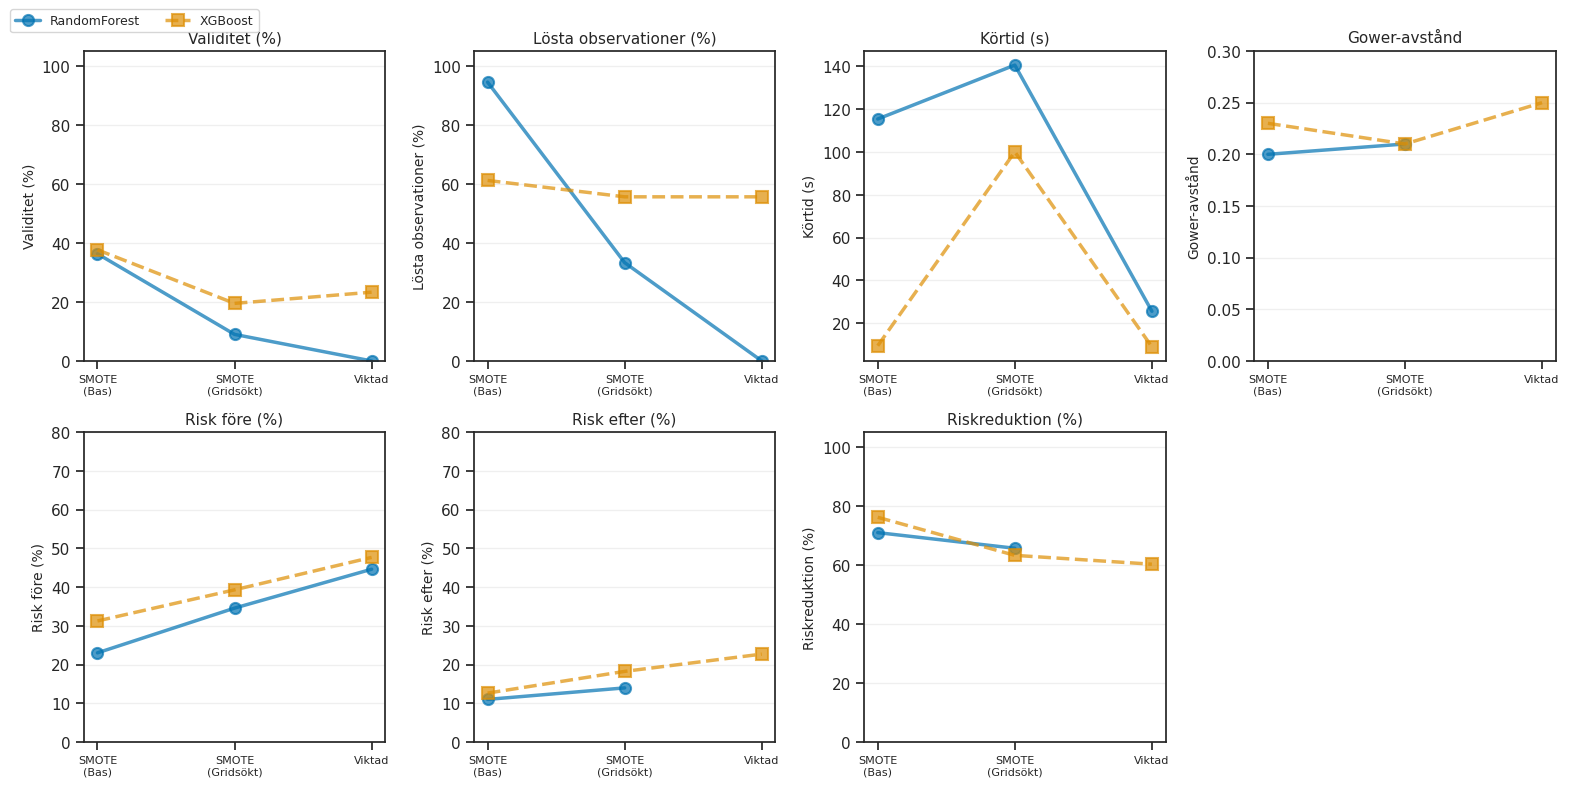

In [13]:
# Combined plot - Swedish version
sns.set_theme(style="ticks")

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Colors and styles
colors = {"RandomForest": "#0173B2", "XGBoost": "#DE8F05"}
linestyles = {"RandomForest": "-", "XGBoost": "--"}
markers = {"RandomForest": "o", "XGBoost": "s"}

# Category mapping
category_map = {
    'SMOTE (Base)': 'SMOTE\n(Bas)',
    'SMOTE (Gridsearched)': 'SMOTE\n(Gridsökt)',
    'Weighted': 'Viktad'
}
category_order = ['SMOTE (Base)', 'SMOTE (Gridsearched)', 'Weighted']
category_numeric = {cat: i for i, cat in enumerate(category_order)}

# Row 1: Performance metrics (4 columns now: Validity, Solved, Time, Gower)
row1_metrics = ["Validity_%", "Solved_%", "Time", "Gower"]
row1_labels = {
    "Validity_%": "Validitet (%)",
    "Solved_%": "Lösta observationer (%)",
    "Time": "Körtid (s)",
    "Gower": "Gower-avstånd"
}

for i, metric in enumerate(row1_metrics):
    ax = axes[0, i]

    for model in ["RandomForest", "XGBoost"]:
        metric_data = df_melted[(df_melted["Model"] == model) & (df_melted["Metric"] == metric)].copy()
        if not metric_data.empty:
            grouped = metric_data.groupby('Category')['Value'].mean().reset_index()
            grouped['x_pos'] = grouped['Category'].map(category_numeric)
            grouped = grouped.sort_values('x_pos')

            ax.plot(
                grouped['x_pos'],
                grouped['Value'],
                marker=markers[model],
                color=colors[model],
                linestyle=linestyles[model],
                markersize=8,
                markeredgewidth=1.5,
                markeredgecolor=colors[model],
                markerfacecolor=colors[model],
                linewidth=2.5,
                alpha=0.7,
                label=model
            )

    ax.set_ylabel(row1_labels[metric], fontsize=10)
    ax.set_title(row1_labels[metric], fontsize=11, fontweight="normal")
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels([category_map[cat] for cat in category_order], fontsize=8)

    if metric in ["Validity_%", "Solved_%"]:
        ax.set_ylim(0, 105)
    elif metric == "Gower":
        ax.set_ylim(0, max(0.3, df_bad["Gower"].max() * 1.1))

# Row 2: Risk metrics (3 columns: Risk Before, Risk After, Risk Reduction)
# Hide the 4th subplot in row 2
axes[1, 3].axis('off')

# Row 2: Risk metrics
row2_metrics = ["Risk_Before", "Risk_After", "Risk_Reduction_%"]
row2_labels = {
    "Risk_Before": "Risk före (%)",
    "Risk_After": "Risk efter (%)",
    "Risk_Reduction_%": "Riskreduktion (%)"
}

for i, metric in enumerate(row2_metrics):
    ax = axes[1, i]

    for model in ["RandomForest", "XGBoost"]:
        metric_data = df_risk_melted[(df_risk_melted["Model"] == model) & (df_risk_melted["Metric"] == metric)].copy()
        if not metric_data.empty:
            grouped = metric_data.groupby('Category')['Value'].mean().reset_index()
            grouped['x_pos'] = grouped['Category'].map(category_numeric)
            grouped = grouped.sort_values('x_pos')

            ax.plot(
                grouped['x_pos'],
                grouped['Value'],
                marker=markers[model],
                color=colors[model],
                linestyle=linestyles[model],
                markersize=8,
                markeredgewidth=1.5,
                markeredgecolor=colors[model],
                markerfacecolor=colors[model],
                linewidth=2.5,
                alpha=0.7,
                label=model
            )
    ax.set_xticklabels([category_map[cat] for cat in category_order], fontsize=8)
    ax.set_ylabel(row2_labels[metric], fontsize=10)
    ax.set_title(row2_labels[metric], fontsize=11, fontweight="normal")
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels([category_map[cat] for cat in category_order], fontsize=8)

    if metric in ["Risk_Before", "Risk_After"]:
        ax.set_ylim(0, max(80, df_risk_melted[df_risk_melted["Metric"].isin(["Risk_Before", "Risk_After"])]["Value"].max() * 1.1))
    elif metric == "Risk_Reduction_%":
        ax.set_ylim(0, 105)

# Create custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color=colors["RandomForest"], marker=markers["RandomForest"],
           markersize=8, markerfacecolor=colors["RandomForest"], markeredgewidth=1.5,
           label='RandomForest', linestyle=linestyles["RandomForest"], linewidth=2.5, alpha=0.7),
    Line2D([0], [0], color=colors["XGBoost"], marker=markers["XGBoost"],
           markersize=8, markerfacecolor=colors["XGBoost"], markeredgewidth=1.5,
           label='XGBoost', linestyle=linestyles["XGBoost"], linewidth=2.5, alpha=0.7),
]

fig.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(0.01, 0.99),
           frameon=True, fontsize=9, ncol=2)

plt.tight_layout()
plt.subplots_adjust(top=0.93, left=0.06, right=0.98)
plt.show()

### English Version - Combined Plot

/tmp/ipykernel_667078/1113142513.py:101: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([category_labels_en[cat] for cat in category_order], fontsize=8)
/tmp/ipykernel_667078/1113142513.py:101: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([category_labels_en[cat] for cat in category_order], fontsize=8)
/tmp/ipykernel_667078/1113142513.py:101: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([category_labels_en[cat] for cat in category_order], fontsize=8)


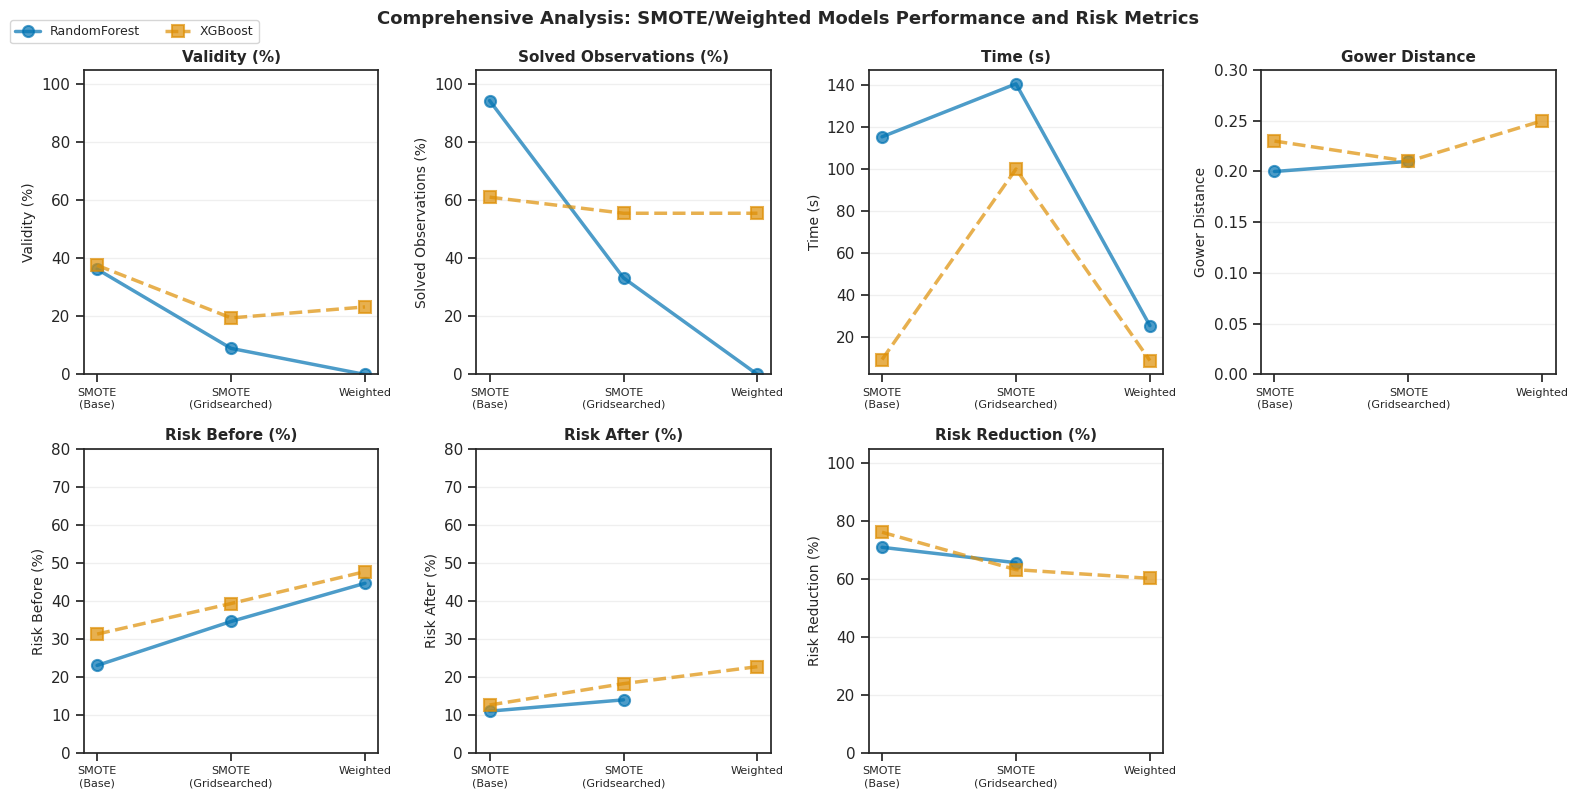

In [14]:
# Combined plot - English version
sns.set_theme(style="ticks")

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Colors and styles
colors = {"RandomForest": "#0173B2", "XGBoost": "#DE8F05"}
linestyles = {"RandomForest": "-", "XGBoost": "--"}
markers = {"RandomForest": "o", "XGBoost": "s"}

# Category mapping
category_labels_en = {
    'SMOTE (Base)': 'SMOTE\n(Base)',
    'SMOTE (Gridsearched)': 'SMOTE\n(Gridsearched)',
    'Weighted': 'Weighted'
}
category_order = ['SMOTE (Base)', 'SMOTE (Gridsearched)', 'Weighted']
category_numeric = {cat: i for i, cat in enumerate(category_order)}

# Row 1: Performance metrics (4 columns now: Validity, Solved, Time, Gower)
row1_metrics = ["Validity_%", "Solved_%", "Time", "Gower"]
row1_labels = {
    "Validity_%": "Validity (%)",
    "Solved_%": "Solved Observations (%)",
    "Time": "Time (s)",
    "Gower": "Gower Distance"
}

for i, metric in enumerate(row1_metrics):
    ax = axes[0, i]

    for model in ["RandomForest", "XGBoost"]:
        metric_data = df_melted[(df_melted["Model"] == model) & (df_melted["Metric"] == metric)].copy()
        if not metric_data.empty:
            grouped = metric_data.groupby('Category')['Value'].mean().reset_index()
            grouped['x_pos'] = grouped['Category'].map(category_numeric)
            grouped = grouped.sort_values('x_pos')

            ax.plot(
                grouped['x_pos'],
                grouped['Value'],
                marker=markers[model],
                color=colors[model],
                linestyle=linestyles[model],
                markersize=8,
                markeredgewidth=1.5,
                markeredgecolor=colors[model],
                markerfacecolor=colors[model],
                linewidth=2.5,
                alpha=0.7,
                label=model
            )

    ax.set_ylabel(row1_labels[metric], fontsize=10)
    ax.set_title(row1_labels[metric], fontsize=11, fontweight="bold")
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels([category_labels_en[cat] for cat in category_order], fontsize=8)

    if metric in ["Validity_%", "Solved_%"]:
        ax.set_ylim(0, 105)
    elif metric == "Gower":
        ax.set_ylim(0, max(0.3, df_bad["Gower"].max() * 1.1))

# Row 2: Risk metrics (3 columns: Risk Before, Risk After, Risk Reduction)
# Hide the 4th subplot in row 2
axes[1, 3].axis('off')

# Row 2: Risk metrics
row2_metrics = ["Risk_Before", "Risk_After", "Risk_Reduction_%"]
row2_labels = {
    "Risk_Before": "Risk Before (%)",
    "Risk_After": "Risk After (%)",
    "Risk_Reduction_%": "Risk Reduction (%)"
}

for i, metric in enumerate(row2_metrics):
    ax = axes[1, i]

    for model in ["RandomForest", "XGBoost"]:
        metric_data = df_risk_melted[(df_risk_melted["Model"] == model) & (df_risk_melted["Metric"] == metric)].copy()
        if not metric_data.empty:
            grouped = metric_data.groupby('Category')['Value'].mean().reset_index()
            grouped['x_pos'] = grouped['Category'].map(category_numeric)
            grouped = grouped.sort_values('x_pos')

            ax.plot(
                grouped['x_pos'],
                grouped['Value'],
                marker=markers[model],
                color=colors[model],
                linestyle=linestyles[model],
                markersize=8,
                markeredgewidth=1.5,
                markeredgecolor=colors[model],
                markerfacecolor=colors[model],
                linewidth=2.5,
                alpha=0.7,
                label=model
            )
    ax.set_xticklabels([category_labels_en[cat] for cat in category_order], fontsize=8)
    ax.set_ylabel(row2_labels[metric], fontsize=10)
    ax.set_title(row2_labels[metric], fontsize=11, fontweight="bold")
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels([category_labels_en[cat] for cat in category_order], fontsize=8)

    if metric in ["Risk_Before", "Risk_After"]:
        ax.set_ylim(0, max(80, df_risk_melted[df_risk_melted["Metric"].isin(["Risk_Before", "Risk_After"])]["Value"].max() * 1.1))
    elif metric == "Risk_Reduction_%":
        ax.set_ylim(0, 105)

# Create custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color=colors["RandomForest"], marker=markers["RandomForest"],
           markersize=8, markerfacecolor=colors["RandomForest"], markeredgewidth=1.5,
           label='RandomForest', linestyle=linestyles["RandomForest"], linewidth=2.5, alpha=0.7),
    Line2D([0], [0], color=colors["XGBoost"], marker=markers["XGBoost"],
           markersize=8, markerfacecolor=colors["XGBoost"], markeredgewidth=1.5,
           label='XGBoost', linestyle=linestyles["XGBoost"], linewidth=2.5, alpha=0.7),
]

fig.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(0.01, 0.99),
           frameon=True, fontsize=9, ncol=2)

fig.suptitle("Comprehensive Analysis: SMOTE/Weighted Models Performance and Risk Metrics",
             fontsize=13, fontweight="bold", y=0.995)

plt.tight_layout()
plt.subplots_adjust(top=0.92, left=0.06, right=0.98)
plt.show()

# Base SMOTE vs threshold

Analyzing SMOTE (Base) experiments across different thresholds to understand threshold effects on CF generation performance.

In [ ]:
# Filter for SMOTE (Base) only
df_smote_base = df_bad[df_bad['Category'] == 'SMOTE (Base)'].copy()
print(f"SMOTE (Base) experiments: {len(df_smote_base)}")
df_smote_base[['Category', 'Model', 'Threshold', 'Validity_%', 'Solved_%', 'Time']]

SMOTE (Base) experiments: 4


,Category,Model,Threshold,Validity_%,Solved_%,Time
0,SMOTE (Base),RandomForest,0.5,31.5,100.0,86.48
1,SMOTE (Base),RandomForest,0.9,41.1,88.9,144.35
2,SMOTE (Base),XGBoost,0.5,33.3,55.6,9.40
3,SMOTE (Base),XGBoost,0.9,42.0,66.7,9.55


In [ ]:
# Reshape SMOTE (Base) data for threshold analysis
df_smote_base_melted = df_smote_base.melt(
    id_vars=["Model", "Threshold"],
    value_vars=["Validity_%", "Solved_%", "Time"],
    var_name="Metric",
    value_name="Value"
)

df_smote_base_risk = df_smote_base.melt(
    id_vars=["Model", "Threshold"],
    value_vars=["Risk_Before", "Risk_After", "Risk_Reduction_%"],
    var_name="Metric",
    value_name="Value"
)

print("Performance metrics:")
print(df_smote_base_melted.head())
print("\nRisk metrics:")
print(df_smote_base_risk.head())

Performance metrics:
          Model  Threshold      Metric  Value
0  RandomForest        0.5  Validity_%   31.5
1  RandomForest        0.9  Validity_%   41.1
2       XGBoost        0.5  Validity_%   33.3
3       XGBoost        0.9  Validity_%   42.0
4  RandomForest        0.5    Solved_%  100.0

Risk metrics:
          Model  Threshold       Metric  Value
0  RandomForest        0.5  Risk_Before  25.71
1  RandomForest        0.9  Risk_Before  20.42
2       XGBoost        0.5  Risk_Before  34.52
3       XGBoost        0.9  Risk_Before  28.07
4  RandomForest        0.5   Risk_After  11.94


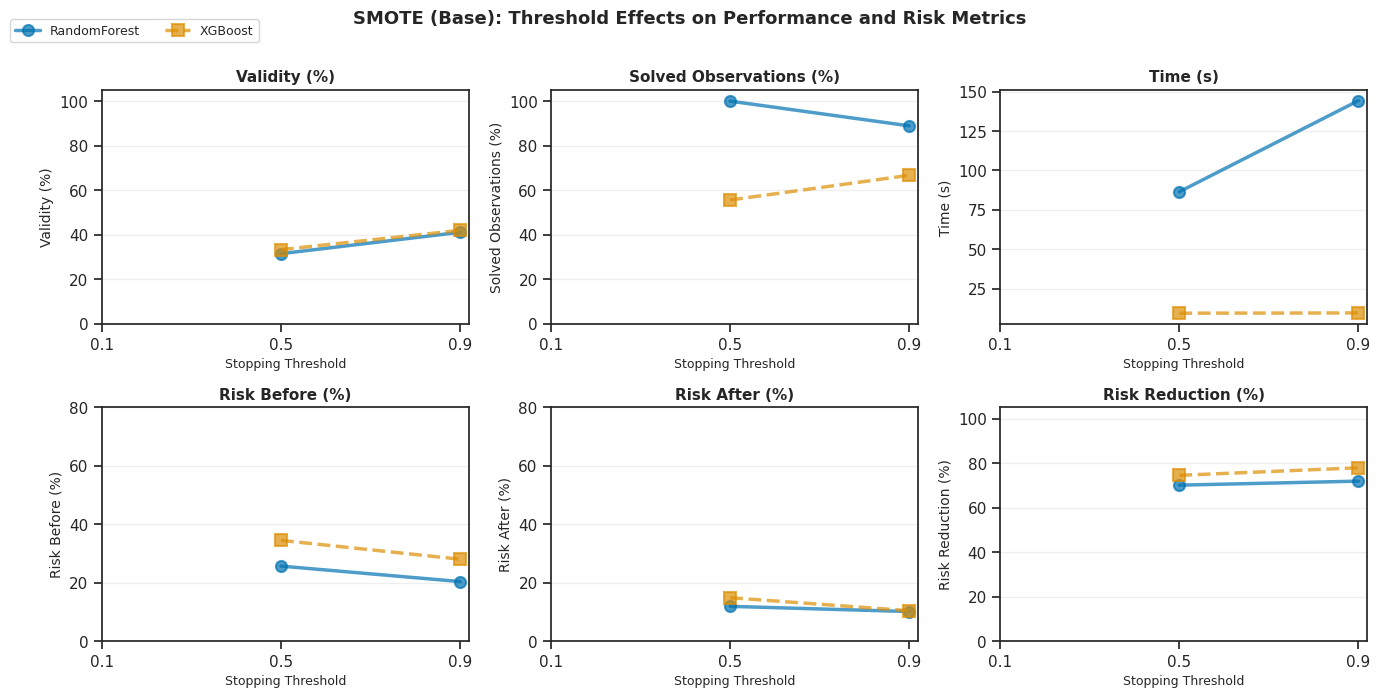

In [ ]:
# SMOTE (Base) vs Threshold - Combined Plot
sns.set_theme(style="ticks")

fig, axes = plt.subplots(2, 3, figsize=(14, 7))

# Colors and styles
colors = {"RandomForest": "#0173B2", "XGBoost": "#DE8F05"}
linestyles = {"RandomForest": "-", "XGBoost": "--"}
markers = {"RandomForest": "o", "XGBoost": "s"}

# Threshold order
threshold_order = [0.1, 0.5, 0.9]

# Row 1: Performance metrics
row1_metrics = ["Validity_%", "Solved_%", "Time"]
row1_labels = {
    "Validity_%": "Validity (%)",
    "Solved_%": "Solved Observations (%)",
    "Time": "Time (s)"
}

for i, metric in enumerate(row1_metrics):
    ax = axes[0, i]

    for model in ["RandomForest", "XGBoost"]:
        metric_data = df_smote_base_melted[(df_smote_base_melted["Model"] == model) &
                                             (df_smote_base_melted["Metric"] == metric)].copy()
        if not metric_data.empty:
            # Sort by threshold
            metric_data = metric_data.sort_values('Threshold')

            ax.plot(
                metric_data['Threshold'],
                metric_data['Value'],
                marker=markers[model],
                color=colors[model],
                linestyle=linestyles[model],
                markersize=8,
                markeredgewidth=1.5,
                markeredgecolor=colors[model],
                markerfacecolor=colors[model],
                linewidth=2.5,
                alpha=0.7,
                label=model
            )

    ax.set_ylabel(row1_labels[metric], fontsize=10)
    ax.set_title(row1_labels[metric], fontsize=11, fontweight="bold")
    ax.set_xlabel("Stopping Threshold", fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_xticks(threshold_order)
    ax.set_xticklabels([str(t) for t in threshold_order])

    if metric in ["Validity_%", "Solved_%"]:
        ax.set_ylim(0, 105)

# Row 2: Risk metrics
row2_metrics = ["Risk_Before", "Risk_After", "Risk_Reduction_%"]
row2_labels = {
    "Risk_Before": "Risk Before (%)",
    "Risk_After": "Risk After (%)",
    "Risk_Reduction_%": "Risk Reduction (%)"
}

for i, metric in enumerate(row2_metrics):
    ax = axes[1, i]

    for model in ["RandomForest", "XGBoost"]:
        metric_data = df_smote_base_risk[(df_smote_base_risk["Model"] == model) &
                                          (df_smote_base_risk["Metric"] == metric)].copy()
        if not metric_data.empty:
            # Sort by threshold
            metric_data = metric_data.sort_values('Threshold')

            ax.plot(
                metric_data['Threshold'],
                metric_data['Value'],
                marker=markers[model],
                color=colors[model],
                linestyle=linestyles[model],
                markersize=8,
                markeredgewidth=1.5,
                markeredgecolor=colors[model],
                markerfacecolor=colors[model],
                linewidth=2.5,
                alpha=0.7,
                label=model
            )

    ax.set_ylabel(row2_labels[metric], fontsize=10)
    ax.set_title(row2_labels[metric], fontsize=11, fontweight="bold")
    ax.set_xlabel("Stopping Threshold", fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_xticks(threshold_order)
    ax.set_xticklabels([str(t) for t in threshold_order])

    if metric in ["Risk_Before", "Risk_After"]:
        ax.set_ylim(0, max(80, df_smote_base_risk[df_smote_base_risk["Metric"].isin(["Risk_Before", "Risk_After"])]["Value"].max() * 1.1))
    elif metric == "Risk_Reduction_%":
        ax.set_ylim(0, 105)

# Create custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color=colors["RandomForest"], marker=markers["RandomForest"],
           markersize=8, markerfacecolor=colors["RandomForest"], markeredgewidth=1.5,
           label='RandomForest', linestyle=linestyles["RandomForest"], linewidth=2.5, alpha=0.7),
    Line2D([0], [0], color=colors["XGBoost"], marker=markers["XGBoost"],
           markersize=8, markerfacecolor=colors["XGBoost"], markeredgewidth=1.5,
           label='XGBoost', linestyle=linestyles["XGBoost"], linewidth=2.5, alpha=0.7),
]

fig.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(0.01, 0.99),
           frameon=True, fontsize=9, ncol=2)

fig.suptitle("SMOTE (Base): Threshold Effects on Performance and Risk Metrics",
             fontsize=13, fontweight="bold", y=0.995)

plt.tight_layout()
plt.subplots_adjust(top=0.88, left=0.08)
plt.show()

### Alternative: Bar Chart Version

Bar charts may be more suitable for categorical threshold comparisons.

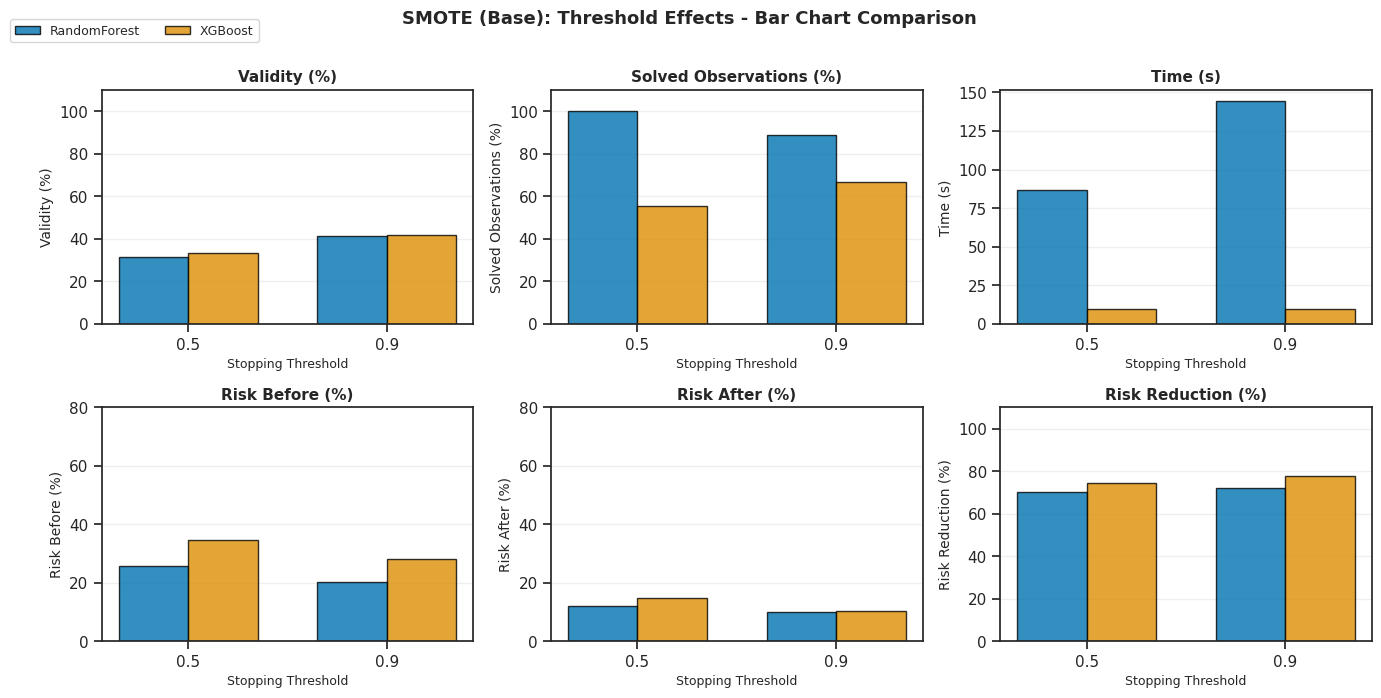

In [ ]:
# SMOTE (Base) vs Threshold - Bar Chart Version
sns.set_theme(style="ticks")

fig, axes = plt.subplots(2, 3, figsize=(14, 7))

# Colors for models
colors = {"RandomForest": "#0173B2", "XGBoost": "#DE8F05"}

# Get unique thresholds and models
thresholds = sorted(df_smote_base['Threshold'].unique())
models = ["RandomForest", "XGBoost"]

# Set up bar positions
x = np.arange(len(thresholds))
width = 0.35

# Row 1: Performance metrics
row1_metrics = ["Validity_%", "Solved_%", "Time"]
row1_labels = {
    "Validity_%": "Validity (%)",
    "Solved_%": "Solved Observations (%)",
    "Time": "Time (s)"
}

for i, metric in enumerate(row1_metrics):
    ax = axes[0, i]

    for j, model in enumerate(models):
        metric_data = df_smote_base_melted[(df_smote_base_melted["Model"] == model) &
                                             (df_smote_base_melted["Metric"] == metric)].copy()
        if not metric_data.empty:
            metric_data = metric_data.sort_values('Threshold')
            values = metric_data['Value'].values

            # Offset bars for each model
            offset = width * (j - 0.5)
            ax.bar(x + offset, values, width, label=model,
                   color=colors[model], alpha=0.8, edgecolor='black', linewidth=1)

    ax.set_ylabel(row1_labels[metric], fontsize=10)
    ax.set_title(row1_labels[metric], fontsize=11, fontweight="bold")
    ax.set_xlabel("Stopping Threshold", fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels([str(t) for t in thresholds])
    ax.grid(True, alpha=0.3, axis='y')

    if metric in ["Validity_%", "Solved_%"]:
        ax.set_ylim(0, 110)

# Row 2: Risk metrics
row2_metrics = ["Risk_Before", "Risk_After", "Risk_Reduction_%"]
row2_labels = {
    "Risk_Before": "Risk Before (%)",
    "Risk_After": "Risk After (%)",
    "Risk_Reduction_%": "Risk Reduction (%)"
}

for i, metric in enumerate(row2_metrics):
    ax = axes[1, i]

    for j, model in enumerate(models):
        metric_data = df_smote_base_risk[(df_smote_base_risk["Model"] == model) &
                                          (df_smote_base_risk["Metric"] == metric)].copy()
        if not metric_data.empty:
            metric_data = metric_data.sort_values('Threshold')
            values = metric_data['Value'].values

            # Offset bars for each model
            offset = width * (j - 0.5)
            ax.bar(x + offset, values, width, label=model,
                   color=colors[model], alpha=0.8, edgecolor='black', linewidth=1)

    ax.set_ylabel(row2_labels[metric], fontsize=10)
    ax.set_title(row2_labels[metric], fontsize=11, fontweight="bold")
    ax.set_xlabel("Stopping Threshold", fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels([str(t) for t in thresholds])
    ax.grid(True, alpha=0.3, axis='y')

    if metric in ["Risk_Before", "Risk_After"]:
        ax.set_ylim(0, max(80, df_smote_base_risk[df_smote_base_risk["Metric"].isin(["Risk_Before", "Risk_After"])]["Value"].max() * 1.15))
    elif metric == "Risk_Reduction_%":
        ax.set_ylim(0, 110)

# Add legend
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper left', bbox_to_anchor=(0.01, 0.99),
           frameon=True, fontsize=9, ncol=2)

fig.suptitle("SMOTE (Base): Threshold Effects - Bar Chart Comparison",
             fontsize=13, fontweight="bold", y=0.995)

plt.tight_layout()
plt.subplots_adjust(top=0.88, left=0.08)
plt.show()